# Project 02: Cross-Sectional Return Direction Classifier
**Objective:** Develop an end-to-end supervised machine learning pipeline using `scikit-learn` to predict the one-month forward return sign ($R_{t \rightarrow t+1} > 0$) across a panel of liquid equities, testing the predictive validity of the technical factors engineered in Project 01.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate, GridSearchCV

In [2]:
screening_dataset = pd.read_parquet("../data/screener_results.parquet")

sector_map = {("NVDA", "MSFT", "MSTR"): "Tech", ("JPM", "BAC", "MS"): "Financials", 
              ("LLY", "JNJ", "ABBV"): "Healthcare", ("XOM", "CVX", "COP"): "Energy",
              ("PG", "KO", "PEP"): "Consumer Staples", "SPY": "Market"}

flat_sector_map = {ticker: sector for tickers, sector in sector_map.items() for ticker in (tickers if isinstance(tickers, tuple) else [tickers])}

# Extract the End-of-Month (EoM) snapshots and aggregate the investable universe
monthly_portfolio = (
    screening_dataset
    .groupby(['ticker', pd.Grouper(key='date', freq='ME')]).last() # Isolate the last trading day per month
    .reset_index()
)

assert monthly_portfolio.groupby('ticker')['date'].apply(lambda s: s.is_monotonic_increasing).all(), "Non monotone dates in at least one ticker — shift(-1) would calculate the wrong forward return"

# Adding of the column containing the sector linked to the ticker
monthly_portfolio['gics_sector'] = monthly_portfolio['ticker'].map(flat_sector_map)
# Computation of the column representing the return at one month
monthly_portfolio["forward_1m_return"] = monthly_portfolio.groupby("ticker")["close"].shift(-1) / monthly_portfolio["close"] -1
# Dropping of NaN values for cold start and last month of the dataset for every ticker
monthly_portfolio = monthly_portfolio.dropna().reset_index(drop=True)
# Creation of target variable: 1 if the forward return is positive, 0 otherwise
monthly_portfolio["target_class"] = (monthly_portfolio["forward_1m_return"] > 0).astype(int)

assert monthly_portfolio['forward_1m_return'].isna().sum() == 0, "Leakage/Null error: Found NaNs in target"
assert set(monthly_portfolio['target_class'].unique()).issubset({0, 1}), "Target class must be binary"

display(monthly_portfolio.info())

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ticker             400 non-null    str           
 1   date               400 non-null    datetime64[ms]
 2   close              400 non-null    float64       
 3   momentum_126d      400 non-null    float64       
 4   rolling_vol_63d    400 non-null    float64       
 5   current_dd_126d    400 non-null    float64       
 6   is_investable      400 non-null    bool          
 7   gics_sector        400 non-null    str           
 8   forward_1m_return  400 non-null    float64       
 9   target_class       400 non-null    int64         
dtypes: bool(1), datetime64[ms](1), float64(5), int64(1), str(2)
memory usage: 33.5 KB


None

### Dataset Construction & Target Engineering
The daily feature store from Project 01 was downsampled to an End-of-Month (EoM) panel to match a discrete monthly portfolio rebalancing horizon. Tickers were mapped to their respective GICS sectors to capture cross-sectional industry effects. 

The target variable `forward_1m_return` was computed strictly via grouped shift:
$$R_{t \rightarrow t+1} = \frac{P_{t+1}}{P_t} - 1$$
The continuous forward return was binarized into `target_class` $\in \{0, 1\}$. Cold-start periods and the final trailing month (which lacks a future return observation) were purged to prevent label leakage.

In [3]:
# Selection of feature and target columns
feature_cols = ["momentum_126d", "rolling_vol_63d", "current_dd_126d", "gics_sector"]
target_col = "target_class"
# Creation of the train dataset
train_dataset = monthly_portfolio[(monthly_portfolio["date"] <= "2024-06-30") & (monthly_portfolio["ticker"] != "SPY")].reset_index(drop=True)
X_train = train_dataset[feature_cols]
y_train = train_dataset[target_col]
# Creation of the test dataset
test_dataset = monthly_portfolio[(monthly_portfolio["date"] > "2024-06-30") & (monthly_portfolio["ticker"] != "SPY")].reset_index(drop=True)
X_test = test_dataset[feature_cols]
y_test = test_dataset[target_col]
# Copy of date and ticker for analysis
test_metadata = test_dataset[["date", "ticker"]].copy()

In [4]:
numeric_features = ['momentum_126d', 'rolling_vol_63d', 'current_dd_126d']
categorical_features = ["gics_sector"]
# Transformation routing
preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_features), 
                  ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
# Pipeline assembling
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            l1_ratio=0,          # Ridge regularization to handle collinearity post one-hot (same as penalty='l2')
            C=1.0,               # Inverse regularization strength
            solver='lbfgs',      # Quasi-Newton optimization algorithm
            max_iter=1000,       # Guarantees convergence on scaled features
            random_state=42      # Strict numerical reproducibility
            )
        )
    ]
)
# Pipeline fit
pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

### Temporal Split & Leakage-Free Pipeline Architecture
A strict chronological boundary was enforced instead of randomized k-fold partitioning to eliminate look-ahead bias and forward-looking data snooping. 

Preprocessing and estimator execution are encapsulated in a unified `Pipeline`:
1. Continuous risk features (`momentum_126d`, `rolling_vol_63d`, `current_dd_126d`) are standardized using `StandardScaler` fitted strictly on in-sample training data.
2. The categorical industry feature (`gics_sector`) is one-hot encoded with `handle_unknown='ignore'`.
3. The classification baseline is estimated via an $L_2$-regularized `LogisticRegression`.

=== BASELINE LOGISTIC REGRESSION: OUT-OF-SAMPLE REPORT ===
              precision    recall  f1-score   support

    Down (0)       0.73      0.28      0.40        40
      Up (1)       0.52      0.89      0.65        35

    accuracy                           0.56        75
   macro avg       0.62      0.58      0.53        75
weighted avg       0.63      0.56      0.52        75



,Predicted Down (0),Predicted Up (1)
Actual Down (0),11,29
Actual Up (1),4,31


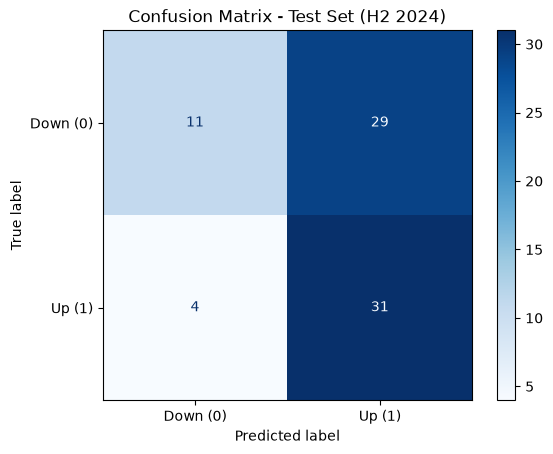

In [5]:
# Output display
print("=== BASELINE LOGISTIC REGRESSION: OUT-OF-SAMPLE REPORT ===")
print(classification_report(y_test, preds, target_names=['Down (0)', 'Up (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
cm_df = pd.DataFrame(
    cm, 
    index=['Actual Down (0)', 'Actual Up (1)'], 
    columns=['Predicted Down (0)', 'Predicted Up (1)']
)
display(cm_df)

# Graphical visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down (0)', 'Up (1)'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Test Set (H2 2024)")
plt.show()

In [6]:
comparison = test_metadata.copy()
comparison["actual_target"] = y_test.values
comparison['ml_signal'] = preds
comparison['screener_signal'] = test_dataset['is_investable'].astype(int).values

assert comparison.shape[0] == 75, "Dimensionality error in comparison dataframe."
assert comparison['ml_signal'].isin([0, 1]).all(), "ML signals must be boolean/binary."
assert comparison['screener_signal'].isin([0, 1]).all(), "Screener signals must be boolean/binary."

# Computation of agreement rate
agreement_mask = comparison['ml_signal'] == comparison['screener_signal']
agreement_rate = agreement_mask.mean()

print(f"Signal Agreement Rate (ML vs Screener): {agreement_rate:.2%}")

# Divergences analysis
divergence_df = comparison[~agreement_mask]
display(divergence_df.head(10))


Signal Agreement Rate (ML vs Screener): 46.67%


,date,ticker,actual_target,ml_signal,screener_signal
0,2024-07-31,ABBV,1,1,0
1,2024-08-31,ABBV,1,1,0
4,2024-11-30,ABBV,0,1,0
5,2024-07-31,BAC,1,1,0
6,2024-08-31,BAC,0,1,0
7,2024-09-30,BAC,1,1,0
10,2024-07-31,COP,1,1,0
12,2024-09-30,COP,1,1,0
13,2024-10-31,COP,0,1,0
15,2024-07-31,CVX,0,0,1


### Model evaluation vs Heuristic Screener

A formal comparison between the ML predictions and the rule-based screener (Project 01) yields a Signal Agreement Rate of ~46.7%.

This divergence demonstrates the fundamental geometric difference between the two approaches:The screener utilizes non-compensatory orthogonal thresholds (e.g., rejecting an asset outright if volatility strictly exceeds the median).

The $L_2$-regularized Logistic Regression models a compensatory hyperplane, where an exceptionally strong momentum factor can mathematically offset a marginal breach in the volatility threshold, capturing multidimensional risk-reward profiles that rigid Boolean logic misses.

## Model Selection & Walk-Forward Cross-Validation

In [7]:
def panel_walk_forward_split(dates, n_splits=4, test_size_months= 3):
    unique_dates = np.unique(dates)
    n_total = len(unique_dates)
    for i in reversed(range(n_splits)):
        test_start = n_total - test_size_months * (i + 1)
        test_end = n_total - test_size_months * i
        
        test_fold = unique_dates[test_start:test_end]
        train_fold = unique_dates[:test_start]
        train_indices = np.where(np.isin(dates, train_fold))[0]
        test_indices = np.where(np.isin(dates, test_fold))[0]
        yield train_indices, test_indices

### Custom Walk-Forward Cross-Validation
To prevent cross-sectional leakage and look-ahead bias on the panel dataset, a custom expanding-window generator was implemented. The dataset is partitioned into 4 chronological splits, maintaining a fixed 3-month out-of-sample test window per fold while expanding the training history.

In [8]:
for fold_idx, (train_idx, test_idx) in enumerate(panel_walk_forward_split(train_dataset["date"])):
    
    # Extract the corresponding dates
    train_dates = train_dataset["date"].iloc[train_idx]
    test_dates = train_dataset["date"].iloc[test_idx]
    
    # ASSERT 1: Null intersection
    assert(np.isin(train_dates, test_dates).sum() == 0), f"Positional Fold leakage {fold_idx}"
    
    # ASSERT 2: Total absence of Look-Ahead Bias
    assert(train_dates.max() < test_dates.min()), f"Temporal Fold leakage {fold_idx}: Train max {train_dates.max()} >= Test min {test_dates.min()}"
    
    print(f"Fold {fold_idx}: Train Months = {train_dates.nunique()} | Test Months = {test_dates.nunique()} | Max Train: {train_dates.max().date()} | Min Test: {test_dates.min().date()}")

Fold 0: Train Months = 8 | Test Months = 3 | Max Train: 2023-06-30 | Min Test: 2023-07-31
Fold 1: Train Months = 11 | Test Months = 3 | Max Train: 2023-09-30 | Min Test: 2023-10-31
Fold 2: Train Months = 14 | Test Months = 3 | Max Train: 2023-12-31 | Min Test: 2024-01-31
Fold 3: Train Months = 17 | Test Months = 3 | Max Train: 2024-03-31 | Min Test: 2024-04-30


In [ ]:
# Preprocessor redefinition
preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_features), 
                  ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Pipeline redefinition
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            l1_ratio=0,             # Ridge regularization to handle collinearity post one-hot (same as penalty='l2')
            C=1.0,                  # Inverse regularization strength
            solver='lbfgs',         # Quasi-Newton optimization algorithm
            max_iter=1000,          # Guarantees convergence on scaled features
            random_state=42,        # Strict numerical reproducibility
            class_weight='balanced' # Rebalancing of weights
            )
        )
    ]
)

# Research of best parameter C
param_grid = {'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]}
custom_cv = list(panel_walk_forward_split(train_dataset["date"]))
grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=custom_cv, scoring='f1_macro') 
grid_search.fit(X_train, y_train)
# Print of results
print(grid_search.best_params_)
print(grid_search.best_score_)

# Results for every fold
scoring = {
    'f1_macro': 'f1_macro',
    'recall_down': make_scorer(recall_score, pos_label=0),
    'recall_up': make_scorer(recall_score, pos_label=1),
    'roc_auc': 'roc_auc',
}
cv_results = cross_validate(grid_search.best_estimator_, X_train, y_train, cv=custom_cv, scoring=scoring)
pd.DataFrame(cv_results)[[c for c in cv_results if c.startswith('test_')]]
display(cv_results)

# Control on the choice of parameter C. See README "Known Limitations".
cv_results_df = pd.DataFrame(grid_search.cv_results_)
# Selection of only key columns: parameters, mean and standard deviation of test score
display(cv_results_df[['params', 'mean_test_score', 'std_test_score']].sort_values(by='mean_test_score', ascending=False))

{'classifier__C': 10}
0.4321259992531362


{'fit_time': array([0.01400018, 0.01359916, 0.01154256, 0.0090642 ]),
 'score_time': array([0.02015805, 0.01835656, 0.02032566, 0.01787233]),
 'test_f1_macro': array([0.38914027, 0.49760766, 0.37747036, 0.46428571]),
 'test_recall_down': array([0.375     , 0.5       , 0.66666667, 0.52941176]),
 'test_recall_up': array([0.46153846, 0.54545455, 0.27272727, 0.42857143]),
 'test_roc_auc': array([0.46634615, 0.51767677, 0.56060606, 0.51680672])}

,params,mean_test_score,std_test_score
4,{'classifier__C': 10},0.432126,0.050391
5,{'classifier__C': 100},0.432126,0.050391
3,{'classifier__C': 1},0.431549,0.048025
0,{'classifier__C': 0.001},0.415397,0.057351
2,{'classifier__C': 0.1},0.414373,0.054873
1,{'classifier__C': 0.01},0.403713,0.066110


### Hyperparameter Tuning & Pipeline Rebalancing
The Logistic Regression pipeline was updated with `class_weight='balanced'` to actively penalize misclassifications on the minority class (Down months), addressing the historical market bias. A `GridSearchCV` was executed over the custom walk-forward folds to optimize the $L_2$ inverse regularization strength ($C$), scoring strictly on Macro-F1 rather than aggregate accuracy.

=== TUNED (class_weight=balanced, C=10): OUT-OF-SAMPLE REPORT ===
              precision    recall  f1-score   support

    Down (0)       0.52      0.55      0.54        40
      Up (1)       0.45      0.43      0.44        35

    accuracy                           0.49        75
   macro avg       0.49      0.49      0.49        75
weighted avg       0.49      0.49      0.49        75



,Predicted Down (0),Predicted Up (1)
Actual Down (0),22,18
Actual Up (1),20,15


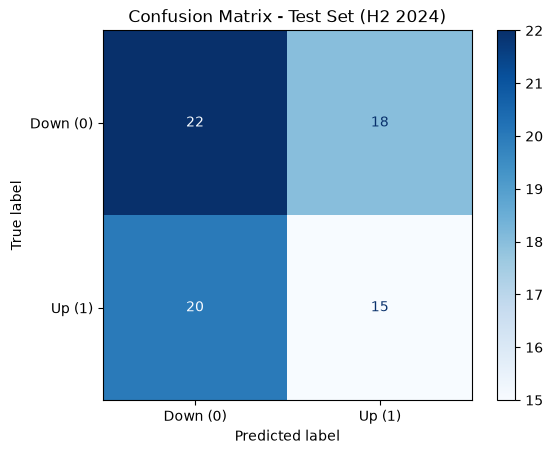

In [10]:
tuned_preds = grid_search.predict(X_test)

# Output display
print("=== TUNED (class_weight=balanced, C=10): OUT-OF-SAMPLE REPORT ===")
print(classification_report(y_test, tuned_preds, target_names=['Down (0)', 'Up (1)']))

# Confusion Matrix
cm_tuned = confusion_matrix(y_test, tuned_preds)
cm_tuned_df = pd.DataFrame(
    cm_tuned, 
    index=['Actual Down (0)', 'Actual Up (1)'], 
    columns=['Predicted Down (0)', 'Predicted Up (1)']
)
display(cm_tuned_df)

# Graphical visualization
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Down (0)', 'Up (1)'])
disp_tuned.plot(cmap='Blues')
plt.title("Confusion Matrix - Test Set (H2 2024)")
plt.show()

In [ ]:
tuned_comparison = test_metadata.copy()
tuned_comparison["actual_target"] = y_test.values
tuned_comparison['ml_signal'] = tuned_preds
tuned_comparison['screener_signal'] = test_dataset['is_investable'].astype(int).values

assert tuned_comparison.shape[0] == 75, "Dimensionality error in comparison dataframe."
assert tuned_comparison['ml_signal'].isin([0, 1]).all(), "ML signals must be boolean/binary."
assert tuned_comparison['screener_signal'].isin([0, 1]).all(), "Screener signals must be boolean/binary."

# Computation of agreement rate
tuned_agreement_mask = tuned_comparison['ml_signal'] == tuned_comparison['screener_signal']
tuned_agreement_rate = tuned_agreement_mask.mean()

print(f"Signal Agreement Rate (ML vs Screener): {tuned_agreement_rate:.2%}")

# Divergences analysis
tuned_divergence_df = tuned_comparison[~tuned_agreement_mask]
display(tuned_divergence_df.head(10))


Signal Agreement Rate (ML vs Screener): 56.00%


,date,ticker,actual_target,ml_signal,screener_signal
2,2024-09-30,ABBV,1,0,1
3,2024-10-31,ABBV,0,0,1
4,2024-11-30,ABBV,0,1,0
5,2024-07-31,BAC,1,1,0
8,2024-10-31,BAC,1,0,1
10,2024-07-31,COP,1,1,0
12,2024-09-30,COP,1,1,0
15,2024-07-31,CVX,0,0,1
19,2024-11-30,CVX,0,0,1
21,2024-08-31,JNJ,0,0,1


### Model Evaluation vs. Heuristic Screener

A formal comparison between the tuned ML predictions and the rule-based screener yields a Signal Agreement Rate of ~56.0%. 

More importantly, the divergence distribution is now symmetrical. Unlike the uncalibrated baseline, which predominantly over-predicted positive returns due to historical market bias, the class-balanced model exhibits a stabilized false positive to false negative ratio. This geometric shift directly reflects the cost-sensitive penalization of minority class misclassifications, capturing risk profiles that rigid Boolean logic discards.